In [1]:
from pathlib import Path
from typing import Any

import geopandas as gpd
import numpy as np
import opera_utils
import rasterio
from matplotlib import pyplot as plt
from pyproj import Transformer
from rasterio.transform import Affine, from_bounds
from rasterio.warp import Resampling, reproject

from venti.log import get_logger
from venti.models import load_itrf, plate_motion

logger = get_logger("venti", enable_file_logging=False)

In [4]:
def make_point_grid(gdf: gpd.GeoDataFrame,
                   cell_size: float = 50000,
                   target_crs: str = "EPSG:4326") -> tuple[np.ndarray, np.ndarray]:
    """Create a regular point grid within a polygon GeoDataFrame.

    Parameters
    ----------
    gdf : GeoDataFrame
        Input polygon(s), assumed to be in EPSG:4326.
    cell_size : float, optional
        Spacing between points in meters (default: 50,000 = 50 km).
    target_crs : str, optional
        CRS for output grid (default: "EPSG:4326").

    Returns
    -------
    x : np.ndarray
        X coordinates of grid points (longitude if EPSG:4326).
    y : np.ndarray
        Y coordinates of grid points (latitude if EPSG:4326).

    Raises
    ------
    ValueError
        If input GeoDataFrame is empty or invalid.

    """
    if gdf.empty:
        msg = "Input GeoDataFrame is empty"
        raise ValueError(msg)

    if gdf.crs is None:
        logger.warning("No CRS defined for input GeoDataFrame, assuming EPSG:4326")
        gdf = gdf.set_crs("EPSG:4326")

    try:
        # Project polygon to UTM for accurate meter-based calculations
        utm_crs = gdf.estimate_utm_crs()
        gdf_proj = gdf.to_crs(utm_crs)
        logger.info(f"Projected to {utm_crs} for grid generation")

        # Get bounds
        minx, miny, maxx, maxy = gdf_proj.total_bounds
        logger.info(f"Bounds: {minx:.0f}, {miny:.0f}, {maxx:.0f}, {maxy:.0f}")

        # Calculate grid dimensions
        width = max(1, int(np.rint((maxx - minx) / cell_size)))
        length = max(1, int(np.rint((maxy - miny) / cell_size)))
        logger.info(f"Grid dimensions: {width} x {length} points")

        # Generate grid coordinates
        gridy, gridx = np.mgrid[maxy:miny:length*1j, minx:maxx:width*1j]

        # Transform back to target CRS
        transformer = Transformer.from_crs(utm_crs, target_crs, always_xy=True)
        x, y = transformer.transform(gridx, gridy)

        logger.info(f"Generated grid with {x.size} points")
        return x, y

    except Exception as e:
        logger.exception(f"Error generating grid: {e}")
        raise

In [5]:
from collections import namedtuple

import geopandas as gpd
import numpy as np

FrameUTM = namedtuple(
    'FrameUTM',
    ['crs', 'bounds', 'transform', 'width', 'height']
)


def get_frame_utm_transform(frame_gdf: gpd.GeoDataFrame,
                           cell_size: int = 30) -> FrameUTM:
    """Get UTM transform parameters for a GeoDataFrame frame.

    Args:
        frame_gdf: GeoDataFrame containing the frame geometry
        cell_size: Cell size in meters for the grid (default: 30)

    Returns:
        FrameUTM namedtuple containing CRS, bounds, transform, width, and height

    """
    utm_crs = frame_gdf.estimate_utm_crs()
    selected_frame_utm = frame_gdf.to_crs(utm_crs)
    minx, miny, maxx, maxy = selected_frame_utm.total_bounds

    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(maxy, miny, -cell_size)

    dst_transform = Affine(cell_size, 0, minx, 0, -cell_size, maxy)
    target_height, target_width = len(ys), len(xs)

    return FrameUTM(
        crs=utm_crs,
        bounds=selected_frame_utm.total_bounds,
        transform=dst_transform,
        width=target_width,
        height=target_height
    )

In [6]:
itrf=2014
frame_id=3060

disp_frame_db = opera_utils.get_frame_geodataframe()
selected_fid = disp_frame_db[disp_frame_db.index==frame_id]
selected_fid

,is_land,is_north_america,orbit_pass,geometry
frame_id,,,,
3060,1,True,DESCENDING,"POLYGON ((-102.03708 37.27968, -101.7256 38.81..."


In [7]:
get_frame_utm_transform(selected_fid)

FrameUTM(crs=<Projected CRS: EPSG:32614>
Name: WGS 84 / UTM zone 14N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°W and 96°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-102.0, 0.0, -96.0, 84.0)
Coordinate Operation:
- name: UTM zone 14N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, bounds=array([ 230731.28448226, 4095471.35550407,  513608.04472937,
       4299275.97516773]), transform=Affine(30.0, 0.0, np.float64(230731.28448225668),
       0.0, -30.0, np.float64(4299275.97516773)), width=9430, height=6794)

In [9]:
load_itrf.get_plate_data('NOAM', date=2014)

{'plate': 'NOAM',
 'name': 'North American Plate',
 'omega_x': 0.0066,
 'omega_y': -0.1928,
 'omega_z': -0.0176}

In [10]:
import logging

import geopandas as gpd
import numpy as np

from venti.models import load_itrf

logger = logging.getLogger(__name__)


def get_frame_pmm(
    frame_gdf: gpd.GeoDataFrame,
    plate: str = "NOAM",
    date: int = 2014,
    grid_posting: float = 10e3
) -> tuple[np.ndarray, np.ndarray, dict[str, Any]]:
    """Generate plate motion model (PMM) velocities for a given frame.

    This function loads International Terrestrial Reference Frame (ITRF) plate
    motion data and models horizontal velocities on a regular grid within the
    specified geographic frame.

    Parameters
    ----------
    frame_gdf : gpd.GeoDataFrame
        GeoDataFrame representing the area of interest for modeling plate motion.
    plate : str, default "NOAM"
        Plate identifier for the tectonic plate of interest (e.g., "NOAM" for
        North American plate).
    date : int, default 2014
        ITRF reference year. Supported values are 2014 and 2020.
    grid_posting : float, default 10e3
        Grid cell size in meters for the velocity model grid spacing.

    Returns
    -------
    Tuple[np.ndarray, np.ndarray, Dict[str, Any]]
        A tuple containing:
        - pmm_east_velocity: 2D array of east-west velocity components (m/year)
        - pmm_north_velocity: 2D array of north-south velocity components (m/year)
        - pmm_attributes: Dictionary containing grid metadata and model information

    Raises
    ------
    ValueError
        If an unsupported ITRF year is specified.

    Notes
    -----
    The function creates a regular grid with the specified posting and models
    plate velocities using Euler pole parameters from the ITRF solution.
    Grid dimensions and coordinate reference system are preserved in the
    returned attributes dictionary.

    """
    # Validate ITRF date input
    supported_itrf_years = [2014, 2020]
    if date not in supported_itrf_years:
        msg = f"ITRF year must be one of {supported_itrf_years}, got {date}"
        raise ValueError(
            msg
        )

    # Load ITRF plate motion model parameters
    logger.info(f"Loading ITRF{date} plate motion data for plate '{plate}'")
    plate_motion_model = load_itrf.get_plate_data(plate, date=date)

    # Generate regular grid for plate motion modeling
    logger.debug(f"Creating grid with {grid_posting/1000:.1f} km spacing")
    grid_longitudes, grid_latitudes = make_point_grid(
        frame_gdf, cell_size=grid_posting
    )

    # Extract grid dimensions for raster attributes
    grid_height, grid_width = grid_longitudes.shape

    # Create geospatial transform for the grid
    grid_transform = from_bounds(
        *frame_gdf.total_bounds,
        width=grid_width,
        height=grid_height
    )

    # Model horizontal plate velocities using Euler pole parameters
    logger.info("Computing plate motion velocities from Euler pole parameters")
    modeled_velocities = plate_motion.model_plate_velocities(
        grid_longitudes.ravel(),
        grid_latitudes.ravel(),
        plate_motion_model['omega_x'],
        plate_motion_model['omega_y'],
        plate_motion_model['omega_z']
    )

    # Reshape velocity components back to 2D grid
    pmm_east_velocity = modeled_velocities[:, 0].reshape(
        (grid_height, grid_width)
    )  # East-West component
    pmm_north_velocity = modeled_velocities[:, 1].reshape(
        (grid_height, grid_width)
    )  # North-South component

    # Compile grid and model metadata
    pmm_attributes = {
        'crs': frame_gdf.crs,
        'width': grid_width,
        'height': grid_height,
        'transform': grid_transform,
        'nodata': np.nan,
        'plate': plate,
        'model': f'ITRF{date}',
        'grid_posting_m': grid_posting,
        'units': 'm/year'
    }

    logger.info(f"Generated {grid_width}x{grid_height} velocity grid for {plate} plate")

    return pmm_east_velocity, pmm_north_velocity, pmm_attributes

In [11]:
pmm_ve, pmm_vn, pmm_attr = get_frame_pmm(selected_fid)
pmm_attr

{'crs': <Geographic 2D CRS: EPSG:4326>
 Name: WGS 84
 Axis Info [ellipsoidal]:
 - Lat[north]: Geodetic latitude (degree)
 - Lon[east]: Geodetic longitude (degree)
 Area of Use:
 - name: World.
 - bounds: (-180.0, -90.0, 180.0, 90.0)
 Datum: World Geodetic System 1984 ensemble
 - Ellipsoid: WGS 84
 - Prime Meridian: Greenwich,
 'width': 28,
 'height': 20,
 'transform': Affine(np.float64(0.11404292857142855), np.float64(0.0), np.float64(-102.037084),
        np.float64(0.0), np.float64(-0.09026390000000006), np.float64(38.810487)),
 'nodata': nan,
 'plate': 'NOAM',
 'model': 'ITRF2014',
 'grid_posting_m': 10000.0,
 'units': 'm/year'}

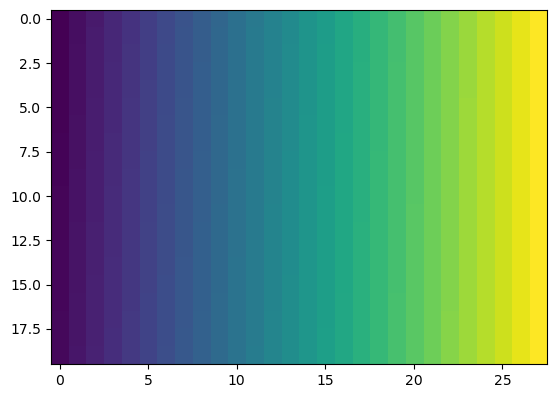

In [12]:

plt.imshow(pmm_vn)

In [13]:
from typing import Any

import geopandas as gpd

from venti.models import load_gia


def get_gia(
    frame_gdf: gpd.GeoDataFrame,
    model: str = "CARON"
) -> tuple[Any, dict[str, Any]]:
    """Load and process Glacial Isostatic Adjustment (GIA) data for a given frame.

    Parameters
    ----------
    frame_gdf : gpd.GeoDataFrame
        GeoDataFrame representing the area of interest for clipping the GIA model.
    model : str, default "CARON"
        Name of the GIA model to use. Supported models are "CARON" and "ICE6".

    Returns
    -------
    Tuple[Any, Dict[str, Any]]
        A tuple containing:
        - gia_raster: Rasterized GIA data
        - gia_attr: Dictionary of attributes including the model name

    Raises
    ------
    ValueError
        If an unsupported GIA model is specified.

    Notes
    -----
    The function clips the GIA model to the provided frame, rasterizes the data
    using the 'vlm_rate' field, and includes model metadata in the attributes.

    For ICE6 model, temporary files are automatically cleaned up after processing.

    """
    # Normalize model name for comparison
    model_upper = model.upper()

    # Load the appropriate GIA model
    if model_upper == 'CARON':
        gia_model = load_gia.load_caron_model(load_gia.CARON_GIA)

    elif model_upper == 'ICE6':
        # Download and load ICE6G model data
        ice6_file_path = Path(load_gia.download_ice6g_data())
        gia_model = load_gia.load_ice6g_model(ice6_file_path)

        # Clean up temporary file
        try:
            ice6_file_path.unlink()
        except FileNotFoundError:
            # File may have already been removed
            pass

    else:
        supported_models = ["CARON", "ICE6"]
        msg = f"GIA model must be one of {supported_models}, got '{model}'"
        raise ValueError(
            msg
        )

    # Clip GIA model to the specified frame area of interest
    gia_frame = load_gia.clip_gia_df(gia_model, aoi=frame_gdf)

    # Rasterize the GIA data using vertical land motion rate
    # TODO: Add uncertainty quantification to the rasterization process
    gia_raster, gia_attributes = load_gia.rasterize_gdf(gia_frame, 'vlm_rate')

    # Add model metadata to attributes
    gia_attributes['model'] = model

    return gia_raster, gia_attributes

In [14]:
gia_model, gia_attr = get_gia(selected_fid)
gia_attr.keys()

dict_keys(['crs', 'width', 'height', 'transform', 'nodata', 'model'])

# EXPORT and project to OPERA DISP frame

In [16]:
out_frame = get_frame_utm_transform(selected_fid)

In [33]:
out_frame

FrameUTM(crs=<Projected CRS: EPSG:32614>
Name: WGS 84 / UTM zone 14N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 102°W and 96°W, northern hemisphere between equator and 84°N, onshore and offshore. Canada - Manitoba; Nunavut; Saskatchewan. Mexico. United States (USA).
- bounds: (-102.0, 0.0, -96.0, 84.0)
Coordinate Operation:
- name: UTM zone 14N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
, bounds=array([ 230731.28448226, 4095471.35550407,  513608.04472937,
       4299275.97516773]), transform=Affine(30.0, 0.0, np.float64(230731.28448225668),
       0.0, -30.0, np.float64(4299275.97516773)), width=9430, height=6794)

In [17]:
#Set output dir
plate = 'NOAM'
itrf = 2014
model = 'CARON'
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

# Output name
output_name = output_dir / f"frame_{frame_id}_{plate}_ITRF{itrf}_GIA_{model}_rates.tif"

In [18]:
resampling_mode: Resampling = Resampling.bilinear
with rasterio.open(
        output_name, "w",
        height=out_frame.height, width=out_frame.width,
        count=3, dtype="float32", crs=out_frame.crs, transform=out_frame.transform,
        nodata=np.nan,
        compress='lzw', tiled=True, blockxsize=512, blockysize=512,
        predictor=2, interleave='band',
    ) as dst:
        dst.set_band_description(1, "North-South (mm/yr)")
        dst.set_band_description(2, "East-West (mm/yr)")
        dst.set_band_description(3, "VLM (mm/yr)")

        out_dict = {"src_transform": pmm_attr['transform'],
                        "src_crs": pmm_attr['crs'],
                        "dst_transform": out_frame.transform,
                        "dst_crs": out_frame.crs,
                        "resampling": resampling_mode,
                        "dst_nodata": np.nan}

        # Interpolate PMM North-South
        logger.info(f"Writing plate NS rates: {output_name} [band: 1]")
        reproject(
            source=pmm_vn,
            destination=rasterio.band(dst, 1),
            **out_dict
        )

        # Interpolate PMM East-West
        logger.info(f"Writing plate EW rates: {output_name} [band: 2]")
        reproject(
            source=pmm_ve,
            destination=rasterio.band(dst, 2),
            **out_dict
        )

        out_dict = {**out_dict, 'src_transform': gia_attr['transform'], 'src_crs': gia_attr['crs']}
        # Interpolate PMM East-West
        logger.info(f"Writing GIA VLM rates: {output_name} [band: 3]")
        reproject(
            source=gia_model,
            destination=rasterio.band(dst, 3),
            **out_dict
        )

logger.info(f"Successfully wrote output to: {output_name}")